# Credit Risk Prediction

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [2]:
df = pd.read_csv('data/credit_risk_dataset.csv')
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [5]:
df_work = df.copy()

In [6]:
df_work.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [7]:
df_work.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [8]:
imputation_col = ['person_emp_length', 'loan_int_rate']

In [9]:
df_work.corr(numeric_only=True)['loan_status']

person_age                   -0.021629
person_income                -0.144449
person_emp_length            -0.082489
loan_amnt                     0.105376
loan_int_rate                 0.335133
loan_status                   1.000000
loan_percent_income           0.379366
cb_person_cred_hist_length   -0.015529
Name: loan_status, dtype: float64

In [10]:
df_work.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


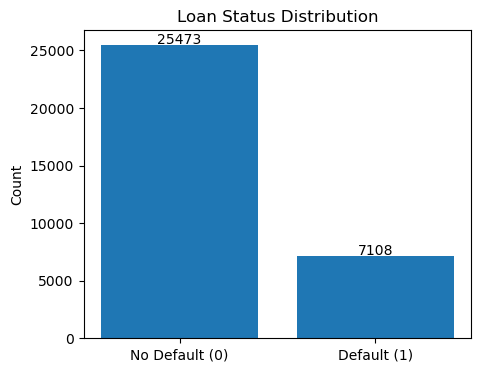

In [11]:
status_counts = df_work["loan_status"].value_counts().sort_index()

plt.figure(figsize=(5,4))
plt.bar(["No Default (0)", "Default (1)"], status_counts.values)
plt.title("Loan Status Distribution")
plt.ylabel("Count")

for i, v in enumerate(status_counts.values):
    plt.text(i, v + 100, str(v), ha="center")

plt.show()

In [12]:
# Numerical Features
numerical_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income','cb_person_cred_hist_length']

#Nominal Categorical features
categorical_cols = ['person_home_ownership','loan_intent', 'cb_person_default_on_file']

#ordinal feature 
ordinal_cols = ['loan_grade']

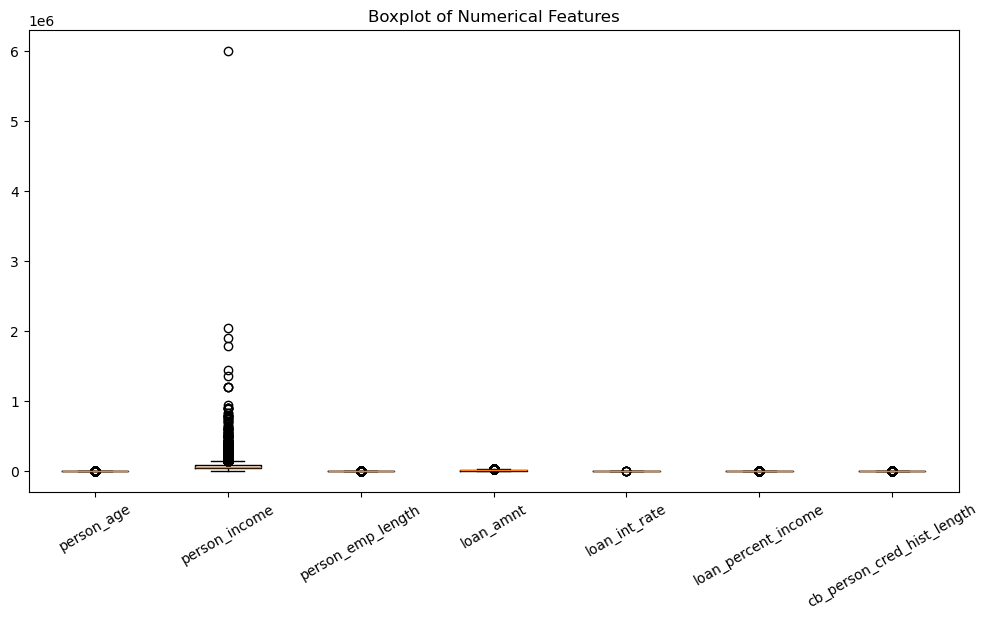

In [13]:
plt.figure(figsize=(12,6))

plt.boxplot(
    [df_work[col].dropna() for col in numerical_cols],
    tick_labels=numerical_cols
)

plt.xticks(rotation=30)
plt.title("Boxplot of Numerical Features")
plt.show()

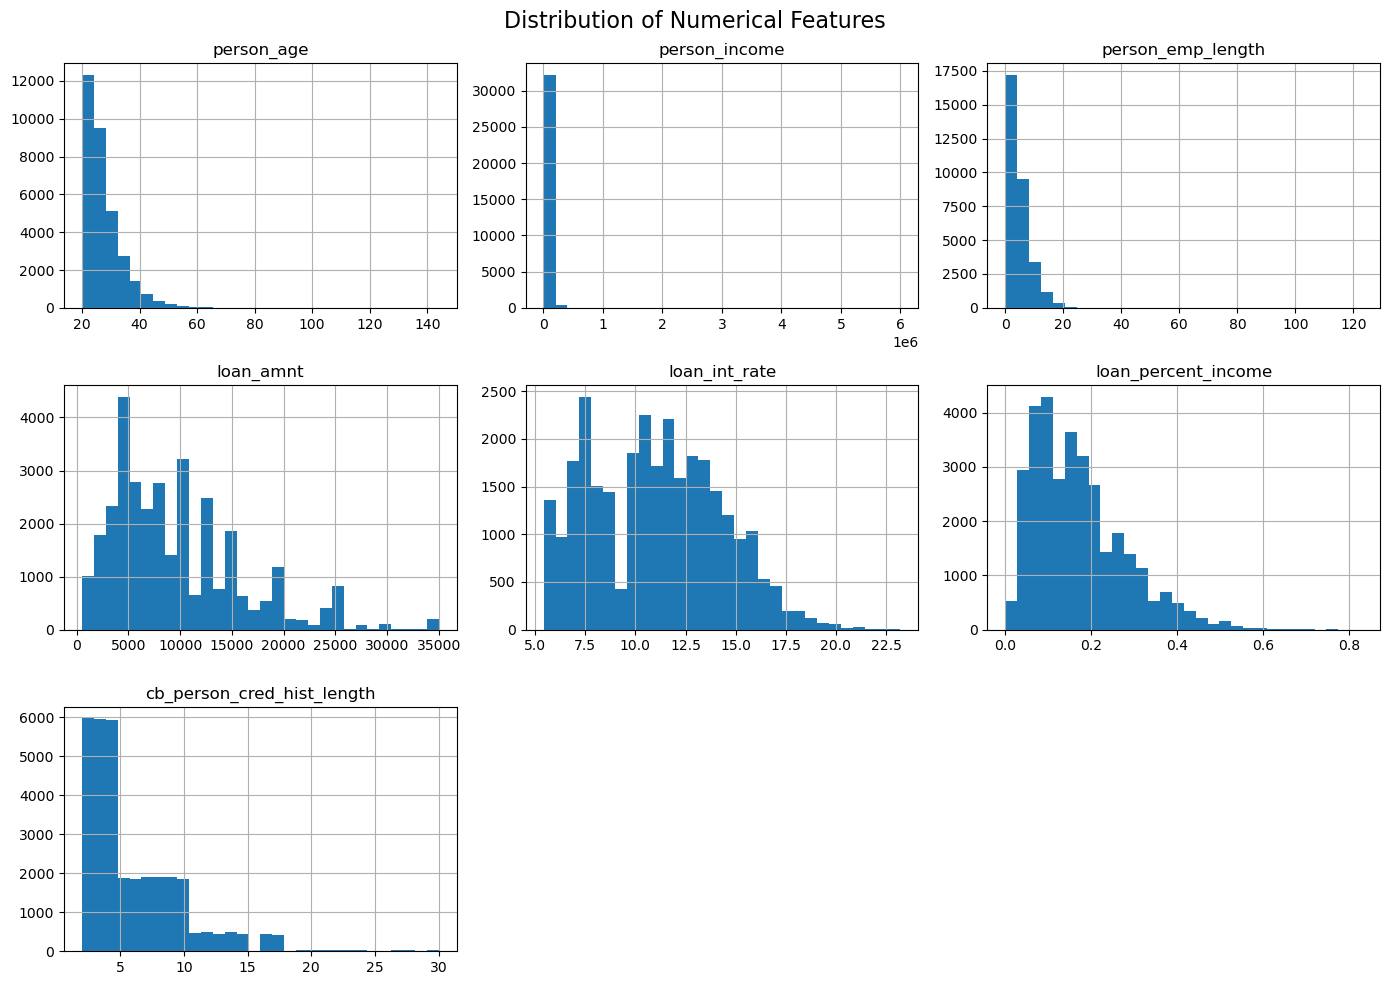

In [14]:
df_work[numerical_cols].hist(figsize=(14,10), bins=30)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

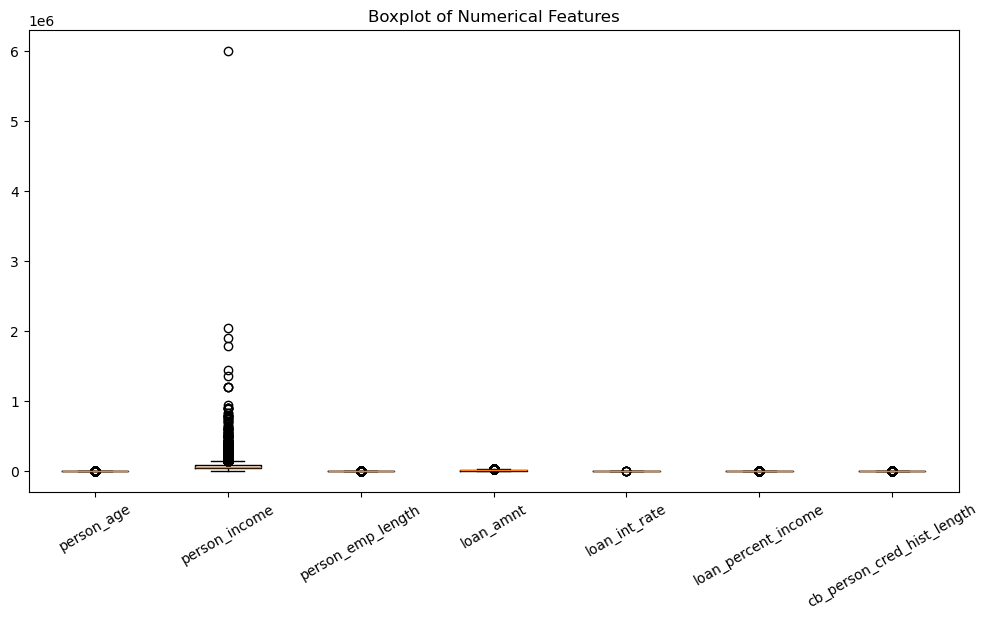

In [15]:
plt.figure(figsize=(12,6))

plt.boxplot(
    [df_work[col].dropna() for col in numerical_cols],
    tick_labels=numerical_cols
)

plt.xticks(rotation=30)
plt.title("Boxplot of Numerical Features")
plt.show()

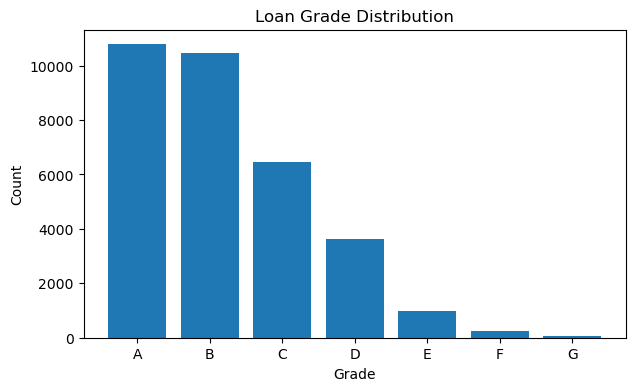

In [16]:
grade_counts = df_work["loan_grade"].value_counts().sort_index()

plt.figure(figsize=(7,4))
plt.bar(grade_counts.index, grade_counts.values)
plt.title("Loan Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.show()

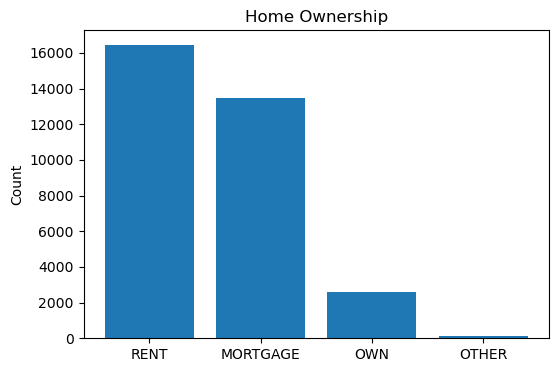

In [17]:
home = df_work["person_home_ownership"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(home.index, home.values)
plt.title("Home Ownership")
plt.ylabel("Count")
plt.show()

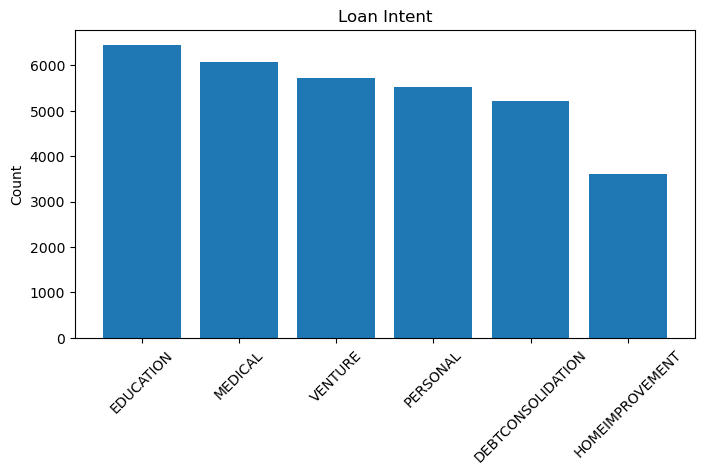

In [18]:
intent = df_work["loan_intent"].value_counts()

plt.figure(figsize=(8,4))
plt.bar(intent.index, intent.values)
plt.xticks(rotation=45)
plt.title("Loan Intent")
plt.ylabel("Count")
plt.show()

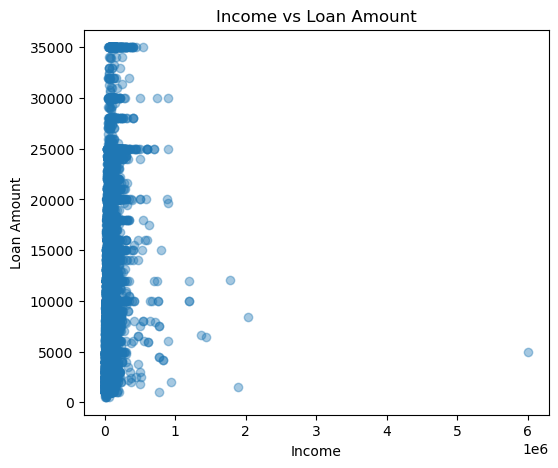

In [19]:
plt.figure(figsize=(6,5))

plt.scatter(
    df_work["person_income"],
    df_work["loan_amnt"],
    alpha=0.4
)

plt.xlabel("Income")
plt.ylabel("Loan Amount")
plt.title("Income vs Loan Amount")
plt.show()

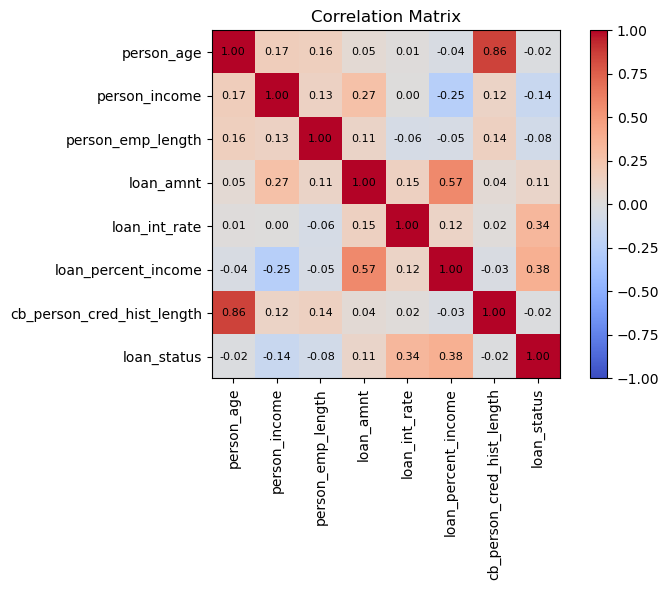

In [20]:
corr = df_work[numerical_cols + ["loan_status"]].corr()

plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}",
                 ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

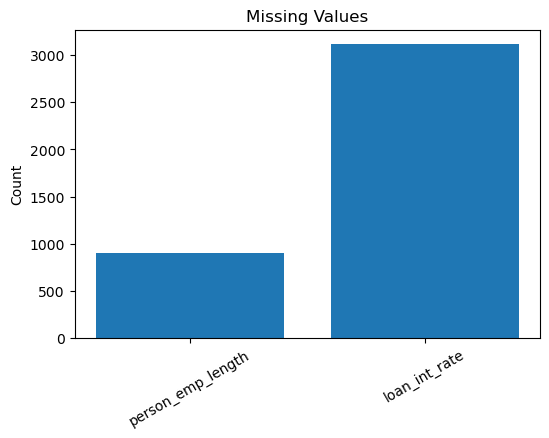

In [21]:
missing = df_work.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(6,4))
plt.bar(missing.index, missing.values)
plt.xticks(rotation=30)
plt.title("Missing Values")
plt.ylabel("Count")
plt.show()

In [22]:
# Numerical Features
numerical_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income','cb_person_cred_hist_length']

#Nominal Categorical features
categorical_cols = ['person_home_ownership','loan_intent', 'cb_person_default_on_file']

#ordinal feature 
ordinal_cols = ['loan_grade']
imputation_cols = ['person_emp_length', 'loan_int_rate']

In [23]:
X = df_work.drop(columns='loan_status')
y = df_work['loan_status']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Numbericcal pipline 
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

#Nominal categorical pipeline 
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

#Ordinal pipeline 
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[['A', 'B', 'C', 'D', 'E', 'F', 'G']
    ]))
])

In [26]:
# Combine everything with the columnTransformer 
preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, numerical_cols), 
    ('categorical', categorical_pipeline, categorical_cols), 
    ('ordinal', ordinal_pipeline, ordinal_cols)
])

In [27]:
#applying in the Support vector machine

In [28]:
from sklearn.model_selection import RandomizedSearchCV

In [29]:
svm_pipeline = Pipeline([
    ('preprocesser', preprocessor), 
    ('svm', SVC())
])

In [ ]:
param_grid = {
    'svm__C': [0.01, 0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf', 'poly'],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1]
}

In [ ]:
grid_svm = RandomizedSearchCV(
    estimator=svm_pipeline, 
    param_distributions=param_grid, 
    n_iter=5, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1, 
    random_state=42, 
    verbose=3
)

In [ ]:
grid_svm.fit(X_train, y_train)